In [2]:
import xml.etree.ElementTree as ET
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

In [3]:
filepath = 'results.xml'
root = ET.parse(filepath).getroot()

data = defaultdict(list)
for __column in root.findall('column'):
    nickname = __column.get('nickname')

    for point in __column.findall('polynom/point'):
        data[nickname].append({
            'x': float(point.get('x')),
            'y': float(point.get('y'))
        })

    data[nickname] = pd.DataFrame(data[nickname])


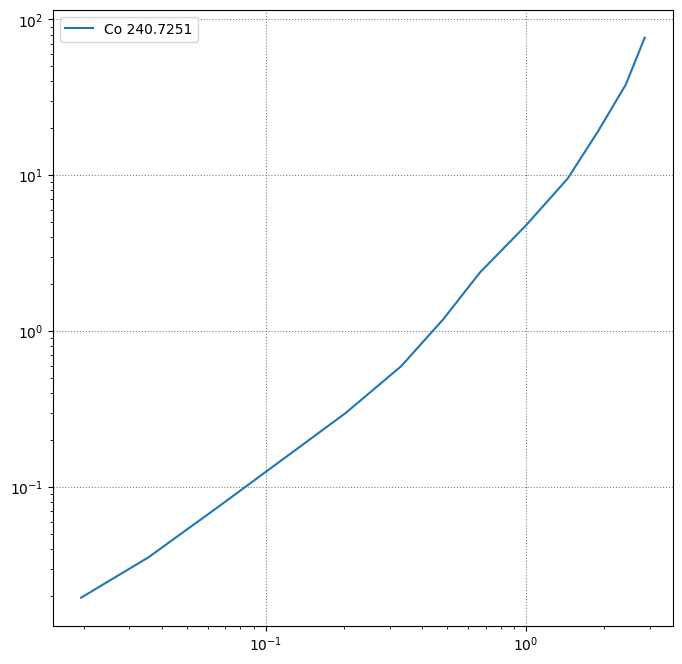

In [4]:
plt.figure(figsize=(8, 8))

for nickname in sorted(data.keys()):
    datum = data[nickname]

    x, y = datum['x'], datum['y']
    plt.plot(
        x, y,
        label=nickname,
    )


plt.xscale('log')
plt.yscale('log')

plt.grid(linestyle=':', color='grey')

plt.legend(loc='upper left')
plt.show()

In [5]:
fig = go.Figure()

for nickname in sorted(data.keys()):
    datum = data[nickname]

    x, y = datum['x'], datum['y']
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines',
        # mode='markers',
        name=nickname,
        showlegend=True,
    ))

spam = []
for datum in data.values():
    spam.extend(datum['x'])
x = np.logspace(np.log10(min(spam)), np.log10(max(spam)), 100)
fig.add_trace(go.Scatter(
    x=x,
    y=x,
    mode='lines',
    name='y = x',
    line=dict(color='black', width=1, dash='dot'),
    showlegend=True
))


fig.update_layout(
    xaxis_type='log',
    yaxis_type='log',
    xaxis_title='x',
    yaxis_title='y',
    width=800,
    height=800,
)

# fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey')
# fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey')

fig.show()